# Data Load & Setting
### Setting

In [2]:
# 필수 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import KFold, train_test_split, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier


# 시각화 설정
plt.style.use('default')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'  # 한글 폰트 설정 (MacOS 기준)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# pandas 출력 옵션 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.colheader_justify', 'center')  # 컬럼 헤더 중앙 정렬

### Data Load

In [3]:
# 데이터 경로 설정
DATA_PATH = '../data/hotel_bookings.csv'
# COLUMNS_INFO_PATH = '../data/columns_info.csv'

In [4]:
# 데이터 파일 확인
print("◼︎ data 폴더 파일 확인")

file_path = '../data'
file_size = os.path.getsize(file_path)

for file in os.listdir(file_path):
    print(f"- {file}: {file_size} bytes")

◼︎ data 폴더 파일 확인
- hotel_bookings.csv: 224 bytes
- images: 224 bytes
- test.csv: 224 bytes
- test_predictions.csv: 224 bytes
- hotel_bookings_data.csv: 224 bytes


In [5]:
df = pd.read_csv(DATA_PATH)
# df_columns = pd.read_csv(COLUMNS_INFO_PATH)

# Data Pre-processing

### N/A Processing

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# inplace=True 대신 재할당 방식 사용 (pandas 3.0 호환)
df['children'] = df['children'].fillna(0)
df['children'] = df['children'].astype(dtype='int64')

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               0
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### New Feature

In [8]:
df['people'] = df['adults'] + df['children'] + df['babies']

In [9]:
# Lead time 카테고리 기능은 현재 사용하지 않음

In [10]:
df['total_stays_date'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

### drop colums

In [11]:
# 사용 여부가 '미사용'인 컬럼명만 출력
not_using_columns = ['hotel',
                     'arrival_date_year',
                     'arrival_date_week_number',
                     'meal',
                    #  'country',
                     'market_segment',
                     'distribution_channel',
                    #  'is_repeated_guest',
                    #  'previous_cancellations',
                    #  'previous_bookings_not_canceled',
                     'assigned_room_type',
                     'deposit_type',
                     'agent',
                     'company',
                     'adults',
                     'children',
                     'babies',
                    #  'lead_time',
                     'reservation_status',
                     'reservation_status_date']

df = df.drop(columns=not_using_columns)


### drop row

In [12]:
df = df[df['people'] != 0].reset_index(drop=True)
df = df[df['adr'] < 1000].reset_index(drop=True)
df

,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_stays_date
0,0,342,July,1,0,0,PRT,0,0,0,C,3,0,Transient,0.00,0,0,2,0
1,0,737,July,1,0,0,PRT,0,0,0,C,4,0,Transient,0.00,0,0,2,0
2,0,7,July,1,0,1,GBR,0,0,0,A,0,0,Transient,75.00,0,0,1,1
3,0,13,July,1,0,1,GBR,0,0,0,A,0,0,Transient,75.00,0,0,1,1
4,0,14,July,1,0,2,GBR,0,0,0,A,0,0,Transient,98.00,0,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119204,0,23,August,30,2,5,BEL,0,0,0,A,0,0,Transient,96.14,0,0,2,7
119205,0,102,August,31,2,5,FRA,0,0,0,E,0,0,Transient,225.43,0,2,3,7
119206,0,34,August,31,2,5,DEU,0,0,0,D,0,0,Transient,157.71,0,4,2,7
119207,0,109,August,31,2,5,GBR,0,0,0,A,0,0,Transient,104.40,0,0,2,7


In [13]:
df['is_canceled'] = df['is_canceled'].astype('category')
df

,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_stays_date
0,0,342,July,1,0,0,PRT,0,0,0,C,3,0,Transient,0.00,0,0,2,0
1,0,737,July,1,0,0,PRT,0,0,0,C,4,0,Transient,0.00,0,0,2,0
2,0,7,July,1,0,1,GBR,0,0,0,A,0,0,Transient,75.00,0,0,1,1
3,0,13,July,1,0,1,GBR,0,0,0,A,0,0,Transient,75.00,0,0,1,1
4,0,14,July,1,0,2,GBR,0,0,0,A,0,0,Transient,98.00,0,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119204,0,23,August,30,2,5,BEL,0,0,0,A,0,0,Transient,96.14,0,0,2,7
119205,0,102,August,31,2,5,FRA,0,0,0,E,0,0,Transient,225.43,0,2,3,7
119206,0,34,August,31,2,5,DEU,0,0,0,D,0,0,Transient,157.71,0,4,2,7
119207,0,109,August,31,2,5,GBR,0,0,0,A,0,0,Transient,104.40,0,0,2,7


### Label incoding

In [14]:
# 범주형 컬럼 추출 (is_canceled 제외)

cat_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_columns = [col for col in cat_columns if col != 'is_canceled']

# 라벨 인코딩
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # 나중에 역변환이 필요할 경우를 위해 저장

print(f"라벨 인코딩된 컬럼 ({len(cat_columns)}개): {cat_columns}")
df

라벨 인코딩된 컬럼 (4개): ['arrival_date_month', 'country', 'reserved_room_type', 'customer_type']


,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_stays_date
0,0,342,5,1,0,0,135,0,0,0,2,3,0,2,0.00,0,0,2,0
1,0,737,5,1,0,0,135,0,0,0,2,4,0,2,0.00,0,0,2,0
2,0,7,5,1,0,1,59,0,0,0,0,0,0,2,75.00,0,0,1,1
3,0,13,5,1,0,1,59,0,0,0,0,0,0,2,75.00,0,0,1,1
4,0,14,5,1,0,2,59,0,0,0,0,0,0,2,98.00,0,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119204,0,23,1,30,2,5,15,0,0,0,0,0,0,2,96.14,0,0,2,7
119205,0,102,1,31,2,5,56,0,0,0,4,0,0,2,225.43,0,2,3,7
119206,0,34,1,31,2,5,43,0,0,0,3,0,0,2,157.71,0,4,2,7
119207,0,109,1,31,2,5,59,0,0,0,0,0,0,2,104.40,0,0,2,7


### One-hot incoding

In [15]:
# One-hot 인코딩은 현재 사용하지 않음 (Label 인코딩 사용)

In [16]:
# 수치형 컬럼 추출 (is_canceled는 타겟 변수이므로 제외)
num_columns = df.select_dtypes(include=[np.number]).columns.tolist()
num_columns

scaler = MinMaxScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])
df

,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_stays_date
0,0,0.464043,0.454545,0.000000,0.000000,0.00,0.762712,0.0,0.0,0.0,0.250,0.166667,0.0,0.666667,0.012355,0.0,0.0,0.018519,0.000000
1,0,1.000000,0.454545,0.000000,0.000000,0.00,0.762712,0.0,0.0,0.0,0.250,0.222222,0.0,0.666667,0.012355,0.0,0.0,0.018519,0.000000
2,0,0.009498,0.454545,0.000000,0.000000,0.02,0.333333,0.0,0.0,0.0,0.000,0.000000,0.0,0.666667,0.157597,0.0,0.0,0.000000,0.014493
3,0,0.017639,0.454545,0.000000,0.000000,0.02,0.333333,0.0,0.0,0.0,0.000,0.000000,0.0,0.666667,0.157597,0.0,0.0,0.000000,0.014493
4,0,0.018996,0.454545,0.000000,0.000000,0.04,0.333333,0.0,0.0,0.0,0.000,0.000000,0.0,0.666667,0.202138,0.0,0.2,0.018519,0.028986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119204,0,0.031208,0.090909,0.966667,0.105263,0.10,0.084746,0.0,0.0,0.0,0.000,0.000000,0.0,0.666667,0.198536,0.0,0.0,0.018519,0.101449
119205,0,0.138399,0.090909,1.000000,0.105263,0.10,0.316384,0.0,0.0,0.0,0.500,0.000000,0.0,0.666667,0.448914,0.0,0.4,0.037037,0.101449
119206,0,0.046133,0.090909,1.000000,0.105263,0.10,0.242938,0.0,0.0,0.0,0.375,0.000000,0.0,0.666667,0.317770,0.0,0.8,0.018519,0.101449
119207,0,0.147897,0.090909,1.000000,0.105263,0.10,0.333333,0.0,0.0,0.0,0.000,0.000000,0.0,0.666667,0.214532,0.0,0.0,0.018519,0.101449


In [17]:
cancel_corr = df.corr()['is_canceled']
cancel_corr.abs().sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.292885
country                           0.264688
total_of_special_requests         0.234871
required_car_parking_spaces       0.195700
booking_changes                   0.144847
previous_cancellations            0.110141
is_repeated_guest                 0.083744
customer_type                     0.068204
reserved_room_type                0.062210
previous_bookings_not_canceled    0.057365
days_in_waiting_list              0.054303
adr                               0.047601
people                            0.044826
stays_in_week_nights              0.025551
total_stays_date                  0.018565
arrival_date_day_of_month         0.005960
stays_in_weekend_nights           0.001313
arrival_date_month                0.001274
Name: is_canceled, dtype: float64

## Modeling

### CatBoost

In [26]:
target = 'is_canceled'

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")
    
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

cb_model = CatBoostClassifier(iterations=100)
cb_model.fit(X_train, y_train)
y_pred = cb_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
conf = confusion_matrix(y_test, y_pred)
clf_report = classification_report(y_test, y_pred)

print("accuracy : ", accuracy)
print("conf :", conf)
print("report :", clf_report)


Training set size: (83446, 18)
Test set size: (35763, 18)
Learning rate set to 0.5
0:	learn: 0.5452764	total: 5.02ms	remaining: 497ms
1:	learn: 0.4818833	total: 8.83ms	remaining: 433ms
2:	learn: 0.4546608	total: 12.4ms	remaining: 400ms
3:	learn: 0.4357962	total: 16.3ms	remaining: 390ms
4:	learn: 0.4220749	total: 20.3ms	remaining: 385ms
5:	learn: 0.4135807	total: 23.3ms	remaining: 366ms
6:	learn: 0.4058324	total: 27.2ms	remaining: 361ms
7:	learn: 0.4016728	total: 30.8ms	remaining: 354ms
8:	learn: 0.3979255	total: 34.3ms	remaining: 347ms
9:	learn: 0.3953878	total: 37.7ms	remaining: 340ms
10:	learn: 0.3929465	total: 41.7ms	remaining: 338ms
11:	learn: 0.3907736	total: 45.6ms	remaining: 334ms
12:	learn: 0.3889688	total: 71.4ms	remaining: 478ms
13:	learn: 0.3873384	total: 79.7ms	remaining: 490ms
14:	learn: 0.3851513	total: 83.4ms	remaining: 473ms
15:	learn: 0.3835552	total: 87ms	remaining: 457ms
16:	learn: 0.3816640	total: 90.9ms	remaining: 444ms
17:	learn: 0.3801728	total: 94.7ms	remaining

In [19]:
# 전체 데이터를 Train(60%) / Validation(20%) / Test(20%)로 분할

# 1단계: Train+Validation (80%) vs Test (20%) 분할
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42, 
    stratify=y_temp
)

In [20]:
# define models to test:
base_models = [("DT_model", DecisionTreeClassifier(random_state=42)),
               ("RF_model", RandomForestClassifier(random_state=42, n_jobs=-1)),
            #    ("LR_model", LogisticRegression(random_state=42, n_jobs=-1)),
               ("XGB_model", XGBClassifier(random_state=42, n_jobs=-1)),
               ("CB_model", CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)),
               ("Gb_model", GradientBoostingClassifier(random_state=42))]

In [21]:
results = []

for name, model in base_models:
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # 평가
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    # # 교차 검증
    # cv_score = cross_validate(model, X_train, y_train, cv=5,
    #                           scoring=['accuracy', 'precision', 'recall', 'f1'])
    
    results.append({
        'model': name,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc#,
        # 'cv_accuracy_mean': np.mean(cv_score['test_accuracy']),
        # 'cv_precision_mean': np.mean(cv_score['test_precision']),
        # 'cv_recall_mean': np.mean(cv_score['test_recall']),
        # 'cv_f1_mean': np.mean(cv_score['test_f1'])
    })

    print(f"Model: {name}")
    print(f"- 훈련 정확도: {train_acc:.4f}")
    print(f"- 검증 정확도: {val_acc:.4f}")
    # print(f"- 교차 검증 정확도 평균: {np.mean(cv_score['test_accuracy']):.4f}")
    # print(f"- 교차 검증 정밀도 평균: {np.mean(cv_score['test_precision']):.4f}")
    # print(f"- 교차 검증 재현율 평균: {np.mean(cv_score['test_recall']):.4f}")
    # print(f"- 교차 검증 F1 스코어 평균: {np.mean(cv_score['test_f1']):.4f}")
    print("====================================")

Model: DT_model
- 훈련 정확도: 0.9957
- 검증 정확도: 0.8207
Model: RF_model
- 훈련 정확도: 0.9957
- 검증 정확도: 0.8687
Model: XGB_model
- 훈련 정확도: 0.8689
- 검증 정확도: 0.8506
Model: CB_model
- 훈련 정확도: 0.8669
- 검증 정확도: 0.8513
Model: Gb_model
- 훈련 정확도: 0.8208
- 검증 정확도: 0.8235


In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='val_accuracy', ascending=False).reset_index(drop=True)
results_df

,model,train_accuracy,val_accuracy
0,RF_model,0.995708,0.868719
1,CB_model,0.866914,0.851313
2,XGB_model,0.868913,0.850600
3,Gb_model,0.820776,0.823463
4,DT_model,0.995736,0.820737


In [23]:
# 최고 성능 모델 선택
best_model_name = results_df.iloc[0]['model']

# base_models에서 해당 모델 찾기
best_model = None
for name, model in base_models:
    if name == best_model_name:
        best_model = model
        break

print(f"최고 성능 모델: {best_model_name}")
print(f"검증 정확도: {results_df.iloc[0]['val_accuracy']:.4f}")
print("="*50)

최고 성능 모델: RF_model
검증 정확도: 0.8687


📊 특성 중요도 분석

특성별 중요도 순위:
lead_time                     : 0.1961 ■■■■■■■■■■■■■■■■■■■
country                       : 0.1543 ■■■■■■■■■■■■■■■
adr                           : 0.1326 ■■■■■■■■■■■■■
arrival_date_day_of_month     : 0.0842 ■■■■■■■■
total_of_special_requests     : 0.0661 ■■■■■■
arrival_date_month            : 0.0587 ■■■■■
customer_type                 : 0.0462 ■■■■
total_stays_date              : 0.0441 ■■■■
previous_cancellations        : 0.0372 ■■■
stays_in_week_nights          : 0.0338 ■■■


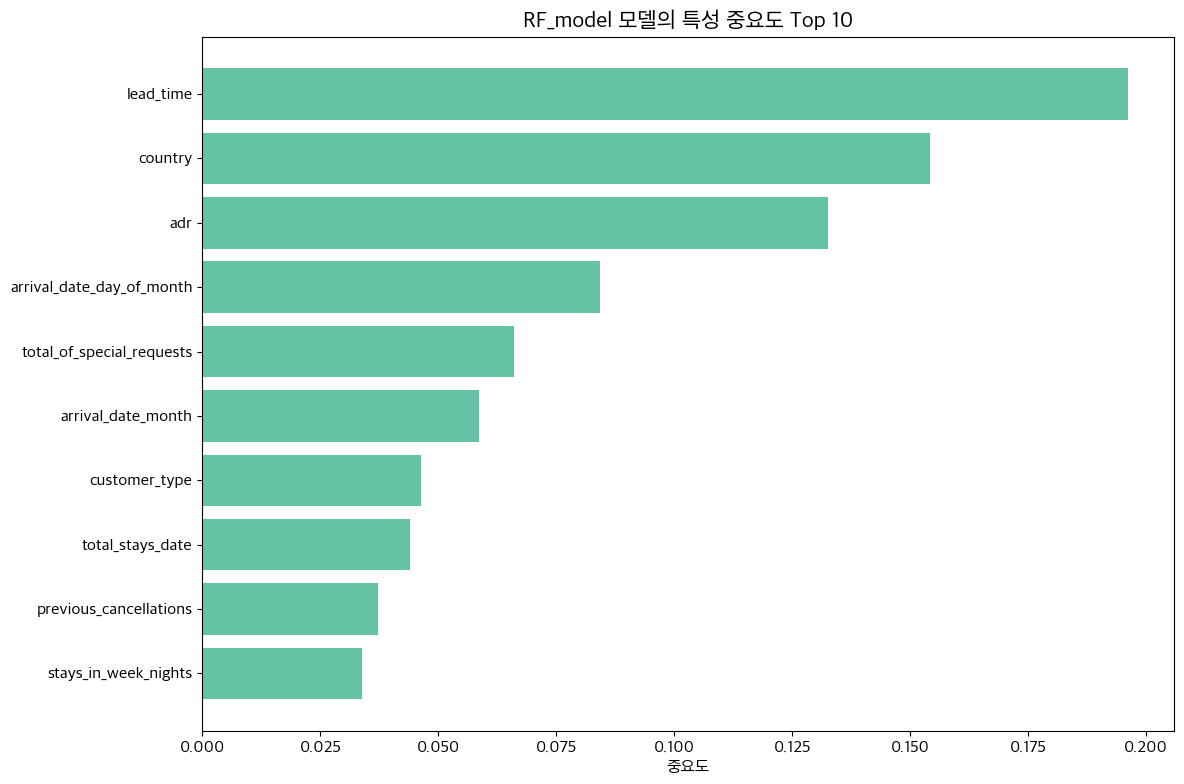

In [24]:
# 특성 중요도 분석 (가능한 모델만)
if best_model is not None and hasattr(best_model, 'feature_importances_'):
    print("📊 특성 중요도 분석")
    print("="*80)
    
    # 특성 중요도 추출
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n특성별 중요도 순위:")
    for idx, row in feature_importance.head(10).iterrows():  # 상위 10개만 표시
        print(f"{row['Feature']:30s}: {row['Importance']:.4f} {'■' * int(row['Importance'] * 100)}")
    
    # 시각화
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('중요도')
    plt.title(f'{best_model_name} 모델의 특성 중요도 Top 10')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
else:
    print(f"📝 {best_model_name} 모델은 특성 중요도를 제공하지 않습니다.")
    print("(Logistic Regression 등은 feature_importances_ 속성이 없음)")

In [25]:

# define models to test:
final_models = [("DT_model", DecisionTreeClassifier(random_state=42)),
               ("RF_model", RandomForestClassifier(random_state=42, n_jobs=-1)),
               ("XGB_model", XGBClassifier(random_state=42, n_jobs=-1)),
               ("CB_model", CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)),
               ("Gb_model", GradientBoostingClassifier(random_state=42))]

voting_clf_soft = VotingClassifier(
    estimators=final_models,
    voting='soft',
    n_jobs=-1
)

voting_clf_soft.fit(X_train, y_train)

y_val_pred_ensemble = voting_clf_soft.predict(X_val)
ensemble_acc = accuracy_score(y_val, y_val_pred_ensemble)
ensemble_recall = recall_score(y_val, y_val_pred_ensemble)
ensemble_f1 = f1_score(y_val, y_val_pred_ensemble)

print(f"Ensemble 모델 성능:")
print(f"- 검증 정확도: {ensemble_acc:.4f}")
print(f"- 검증 재현율: {ensemble_recall:.4f}")
print(f"- 검증 F1 스코어: {ensemble_f1:.4f}")

Ensemble 모델 성능:
- 검증 정확도: 0.8640
- 검증 재현율: 0.7670
- 검증 F1 스코어: 0.8070


### XGBoost